# Práctica de la clase 4
Music Transformer y Vision Transformer
Objetivos:
1. Implementactión de ViT desde cero.
2. Claasificación de imágenes con CIFAR-10
3. Visualización de Patches.
4. Visualización de atención por cabeza.
5. Visualización de Curvas de aprendizaje.
6. Generación de música utilizando un modelo preentrendado de HugginFace.

In [1]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import math
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

SEED = 666
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", DEVICE)

# En equipos CPU/Windows puede evitar saturación de hilos.
torch.set_num_threads(1)

RESULTS_DIR = Path("resultados_practica_clase_4_vit")
RESULTS_DIR.mkdir(exist_ok=True)

# Modo rápido para una práctica de 1.2 horas.
# Si se cuenta con GPU, puedes subir EPOCHS a 10 o 20.
FAST_MODE = True

if FAST_MODE:
    EPOCHS = 3
    MAX_TRAIN_BATCHES = 120
    MAX_TEST_BATCHES = 40
else:
    EPOCHS = 10
    MAX_TRAIN_BATCHES = None
    MAX_TEST_BATCHES = None

BATCH_SIZE = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

IMG_SIZE = 32
PATCH_SIZE = 4
IN_CHANNELS = 3
NUM_CLASSES = 10

D_MODEL = 128
NUM_HEADS = 4
DEPTH = 4
MLP_DIM = 256
DROPOUT = 0.1

# Si no se puede descargar CIFAR-10, se usará FakeData.
USE_FAKE_DATA_IF_CIFAR_FAILS = True

# Bloque opcional de generación musical.
# Por defecto se deja desactivado para no descargar modelos pesados.
RUN_OPTIONAL_MUSIC_DEMO = True

CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

Dispositivo usado: cpu


In [3]:
# ============================================================
# 3. CARGA DE DATASET CIFAR-10
# ============================================================

def get_dataloaders():
    """
    Carga CIFAR-10. Si no hay internet o falla la descarga,
    puede usar FakeData como respaldo para comprobar el flujo.
    """

    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ])

    data_dir = Path("data")
    data_dir.mkdir(exist_ok=True)

    try:
        train_dataset = datasets.CIFAR10(
            root=str(data_dir),
            train=True,
            download=True,
            transform=transform_train
        )

        test_dataset = datasets.CIFAR10(
            root=str(data_dir),
            train=False,
            download=True,
            transform=transform_test
        )

        print("CIFAR-10 cargado correctamente.")

    except Exception as e:
        print("No se pudo cargar CIFAR-10.")
        print("Motivo:", str(e)[:300])

        if not USE_FAKE_DATA_IF_CIFAR_FAILS:
            raise e

        print("Usando FakeData como respaldo para ejecutar la práctica.")

        train_dataset = datasets.FakeData(
            size=3000,
            image_size=(3, IMG_SIZE, IMG_SIZE),
            num_classes=NUM_CLASSES,
            transform=transform_train
        )

        test_dataset = datasets.FakeData(
            size=800,
            image_size=(3, IMG_SIZE, IMG_SIZE),
            num_classes=NUM_CLASSES,
            transform=transform_test
        )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    return train_loader, test_loader


train_loader, test_loader = get_dataloaders()


100%|██████████| 170M/170M [52:19<00:00, 54.3kB/s] 


CIFAR-10 cargado correctamente.


In [4]:
# ============================================================
# 4. FUNCIONES DE VISUALIZACIÓN Y DESNORMALIZACIÓN
# ============================================================

def denormalize_cifar10(tensor):
    """
    Revierte la normalización de CIFAR-10 para visualizar imágenes.
    Entrada: tensor [C, H, W]
    Salida: tensor en rango aproximado [0, 1]
    """
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    tensor = tensor.cpu() * std + mean
    return tensor.clamp(0, 1)


def show_batch_images(loader, num_images=16):
    images, labels = next(iter(loader))
    images = images[:num_images]
    labels = labels[:num_images]

    images_denorm = torch.stack([denormalize_cifar10(img) for img in images])
    grid = make_grid(images_denorm, nrow=4)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Ejemplos del dataset")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ejemplos_dataset.png", dpi=150)
    plt.show()

    print("Etiquetas:")
    print([CIFAR10_CLASSES[int(label)] for label in labels])

In [5]:
# ============================================================
# 5. PATCH EMBEDDING
# ============================================================

class PatchEmbedding(nn.Module):
    """
    Convierte una imagen en una secuencia de patches embebidos.

    Imagen CIFAR-10: [B, 3, 32, 32]
    Patch size = 4
    Número de patches = (32 / 4) * (32 / 4) = 64

    Salida: [B, num_patches, d_model]
    """

    def __init__(self, img_size=32, patch_size=4, in_channels=3, d_model=128):
        super().__init__()

        assert img_size % patch_size == 0, "img_size debe ser divisible por patch_size"

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches_per_side = img_size // patch_size
        self.num_patches = self.num_patches_per_side ** 2

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=d_model,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)                  # [B, d_model, H/P, W/P]
        x = x.flatten(2)                  # [B, d_model, num_patches]
        x = x.transpose(1, 2)             # [B, num_patches, d_model]
        return x

In [6]:
# ============================================================
# 6. MULTI-HEAD SELF-ATTENTION PARA ViT
# ============================================================

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model=128, num_heads=4, dropout=0.1):
        super().__init__()

        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        """
        x: [B, N, d_model]
        N = 1 token CLS + número de patches
        """
        B, N, C = x.shape

        qkv = self.qkv(x)                         # [B, N, 3*d_model]
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)          # [3, B, heads, N, head_dim]

        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attention = torch.softmax(scores, dim=-1)
        attention_drop = self.dropout(attention)

        out = torch.matmul(attention_drop, v)     # [B, heads, N, head_dim]
        out = out.transpose(1, 2).contiguous()    # [B, N, heads, head_dim]
        out = out.reshape(B, N, C)                # [B, N, d_model]
        out = self.out_proj(out)

        if return_attention:
            return out, attention

        return out, None


In [7]:
# ============================================================
# 7. BLOQUE TRANSFORMER ENCODER PARA ViT
# ============================================================

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=4, mlp_dim=256, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attention = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.dropout1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x, return_attention=False):
        attn_out, attention = self.attention(
            self.norm1(x),
            return_attention=return_attention
        )

        x = x + self.dropout1(attn_out)
        x = x + self.mlp(self.norm2(x))

        return x, attention

In [8]:
# ============================================================
# 8. VISION TRANSFORMER DESDE CERO
# ============================================================

class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        d_model=128,
        num_heads=4,
        depth=4,
        mlp_dim=256,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            d_model=d_model
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x, return_attentions=False):
        B = x.size(0)

        x = self.patch_embed(x)                           # [B, patches, d_model]

        cls_tokens = self.cls_token.expand(B, -1, -1)     # [B, 1, d_model]
        x = torch.cat((cls_tokens, x), dim=1)             # [B, patches+1, d_model]

        x = x + self.pos_embed
        x = self.dropout(x)

        attentions = []

        for block in self.blocks:
            x, attention = block(x, return_attention=return_attentions)
            if return_attentions:
                attentions.append(attention)

        x = self.norm(x)

        cls_output = x[:, 0]                              # token CLS
        logits = self.head(cls_output)

        if return_attentions:
            return logits, attentions

        return logits


model = VisionTransformer(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    depth=DEPTH,
    mlp_dim=MLP_DIM,
    dropout=DROPOUT
).to(DEVICE)

print(model)


VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerEncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): MultiHeadSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout1): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,),

In [9]:
# ============================================================
# 9. ENTRENAMIENTO Y EVALUACIÓN
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


def train_one_epoch(model, loader, optimizer, criterion, max_batches=None):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / max(total, 1)
    epoch_acc = correct / max(total, 1)

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, max_batches=None):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / max(total, 1)
    epoch_acc = correct / max(total, 1)

    return epoch_loss, epoch_acc


train_losses = []
train_accs = []
test_losses = []
test_accs = []

print("\nIniciando entrenamiento...\n")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        max_batches=MAX_TRAIN_BATCHES
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        max_batches=MAX_TEST_BATCHES
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
        f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")


Iniciando entrenamiento...

Epoch 01/3 | Train loss: 2.0056 | Train acc: 0.2482 | Test loss: 1.8882 | Test acc: 0.2891
Epoch 02/3 | Train loss: 1.8605 | Train acc: 0.3107 | Test loss: 1.8419 | Test acc: 0.3191
Epoch 03/3 | Train loss: 1.7758 | Train acc: 0.3427 | Test loss: 1.7125 | Test acc: 0.3684


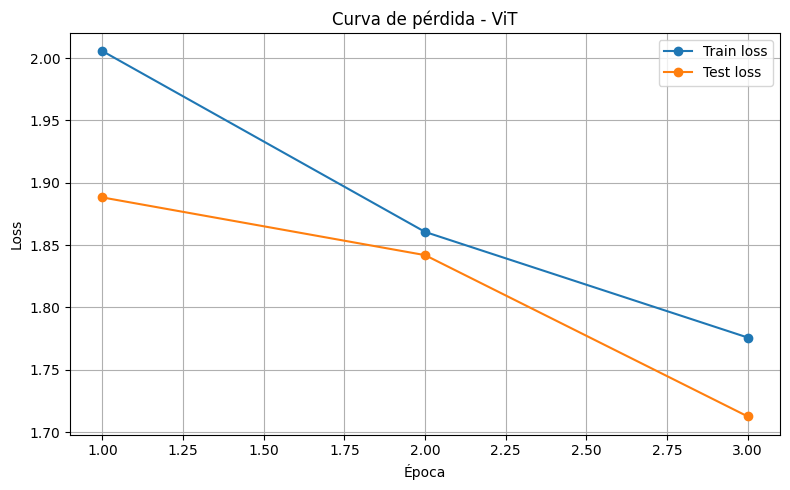

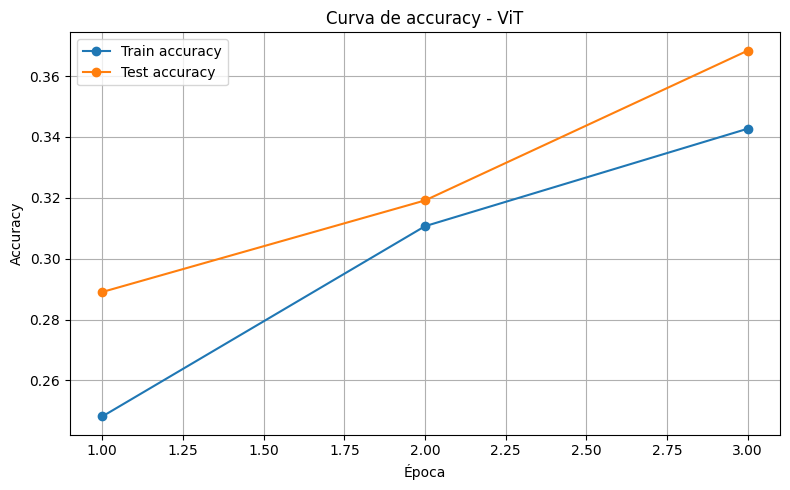

In [10]:
# ============================================================
# 10. CURVAS DE APRENDIZAJE
# ============================================================

def plot_learning_curves():
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, marker="o", label="Train loss")
    plt.plot(epochs, test_losses, marker="o", label="Test loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Curva de pérdida - ViT")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "curva_loss_vit.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_accs, marker="o", label="Train accuracy")
    plt.plot(epochs, test_accs, marker="o", label="Test accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Curva de accuracy - ViT")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "curva_accuracy_vit.png", dpi=150)
    plt.show()


plot_learning_curves()

In [11]:
# ============================================================
# 11. GUARDAR MODELO
# ============================================================

model_path = RESULTS_DIR / "vit_cifar10_desde_cero.pth"
torch.save(model.state_dict(), model_path)
print(f"\nModelo guardado en: {model_path}")


Modelo guardado en: resultados_practica_clase_4_vit\vit_cifar10_desde_cero.pth


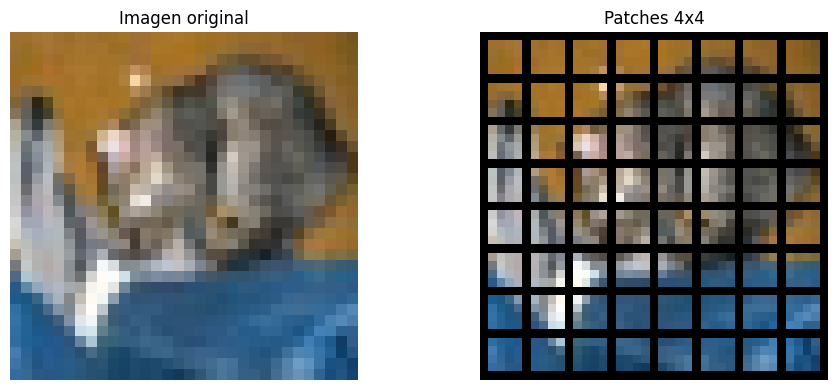

Etiqueta real de imagen ejemplo: cat


In [12]:
# ============================================================
# 12. VISUALIZACIÓN DE PATCHES
# ============================================================


def visualize_patches(image_tensor, patch_size=4, save_path=None):
    """
    Muestra una imagen y su división en patches.
    image_tensor: [3, H, W], normalizada.
    """

    image = denormalize_cifar10(image_tensor)
    C, H, W = image.shape

    patches = []

    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            patch = image[:, i:i + patch_size, j:j + patch_size]
            patches.append(patch)

    patch_grid = make_grid(torch.stack(patches), nrow=H // patch_size, padding=1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(patch_grid.permute(1, 2, 0))
    plt.title(f"Patches {patch_size}x{patch_size}")
    plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)

    plt.show()


images, labels = next(iter(test_loader))
example_image = images[0]
example_label = labels[0]

visualize_patches(
    example_image,
    patch_size=PATCH_SIZE,
    save_path=RESULTS_DIR / "visualizacion_patches.png"
)

print("Etiqueta real de imagen ejemplo:", CIFAR10_CLASSES[int(example_label)])

Predicción de imagen ejemplo: cat


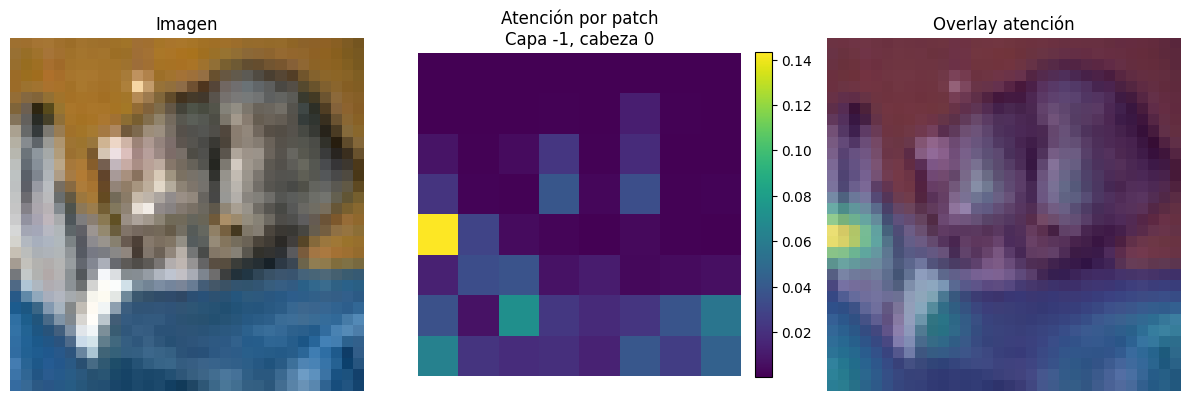

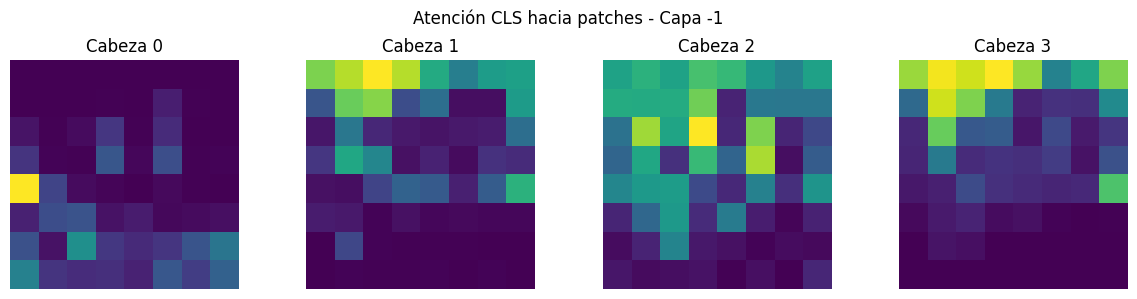

In [13]:
# ============================================================
# 13. VISUALIZACIÓN DE ATENCIÓN DE ViT
# ============================================================

@torch.no_grad()
def get_attention_for_image(model, image_tensor):
    """
    Devuelve logits y atenciones para una imagen.
    image_tensor: [3, H, W]
    """
    model.eval()

    image_batch = image_tensor.unsqueeze(0).to(DEVICE)
    logits, attentions = model(image_batch, return_attentions=True)

    return logits, attentions


def attention_to_grid(attention, head=0, patch_grid_size=8):
    """
    Convierte la atención del token CLS hacia los patches en una matriz 2D.

    attention: [B, heads, N, N]
    N = 1 token CLS + número de patches
    """

    # Atención del CLS token hacia todos los patches.
    cls_attention = attention[0, head, 0, 1:]  # quitar CLS de columnas
    cls_attention = cls_attention.detach().cpu()

    attn_grid = cls_attention.reshape(patch_grid_size, patch_grid_size)

    return attn_grid


def visualize_attention_head(image_tensor, attentions, layer=-1, head=0, save_path=None):
    """
    Visualiza la atención del token CLS hacia los patches.
    """

    image = denormalize_cifar10(image_tensor)
    patch_grid_size = IMG_SIZE // PATCH_SIZE

    attention = attentions[layer]
    attn_grid = attention_to_grid(
        attention,
        head=head,
        patch_grid_size=patch_grid_size
    )

    # Ampliar mapa de atención al tamaño de la imagen.
    attn_resized = F.interpolate(
        attn_grid.unsqueeze(0).unsqueeze(0),
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    ).squeeze()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title("Imagen")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(attn_grid.numpy(), cmap="viridis")
    plt.title(f"Atención por patch\nCapa {layer}, cabeza {head}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(image.permute(1, 2, 0))
    plt.imshow(attn_resized.numpy(), cmap="viridis", alpha=0.55)
    plt.title("Overlay atención")
    plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)

    plt.show()


def visualize_all_heads(image_tensor, attentions, layer=-1, save_path=None):
    """
    Muestra mapas de atención para todas las cabezas de una capa.
    """

    patch_grid_size = IMG_SIZE // PATCH_SIZE
    attention = attentions[layer]
    num_heads = attention.shape[1]

    cols = num_heads
    plt.figure(figsize=(3 * cols, 3))

    for head in range(num_heads):
        attn_grid = attention_to_grid(
            attention,
            head=head,
            patch_grid_size=patch_grid_size
        )

        plt.subplot(1, cols, head + 1)
        plt.imshow(attn_grid.numpy(), cmap="viridis")
        plt.title(f"Cabeza {head}")
        plt.axis("off")

    plt.suptitle(f"Atención CLS hacia patches - Capa {layer}")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)

    plt.show()


logits, attentions = get_attention_for_image(model, example_image)
pred = logits.argmax(dim=1).item()

print("Predicción de imagen ejemplo:", CIFAR10_CLASSES[pred])

visualize_attention_head(
    example_image,
    attentions,
    layer=-1,
    head=0,
    save_path=RESULTS_DIR / "atencion_cabeza_0.png"
)

visualize_all_heads(
    example_image,
    attentions,
    layer=-1,
    save_path=RESULTS_DIR / "atencion_todas_las_cabezas.png"
)

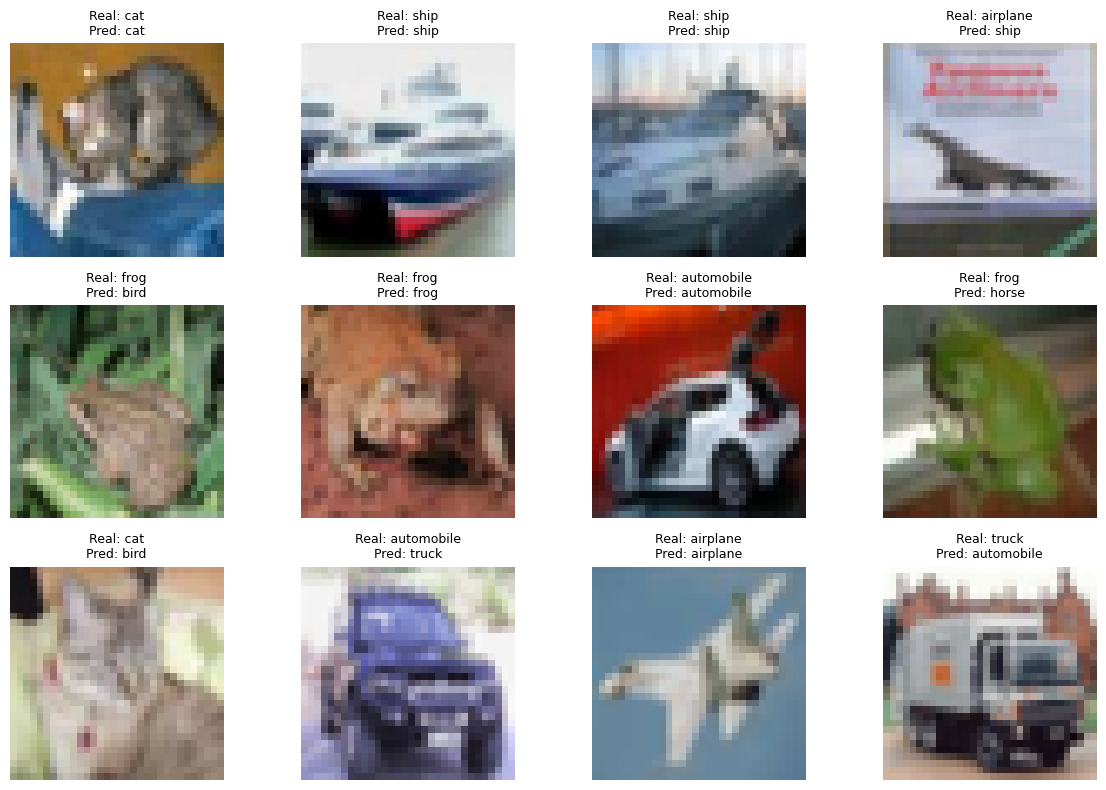

In [14]:
# ============================================================
# 14. PREDICCIONES SOBRE VARIAS IMÁGENES
# ============================================================

@torch.no_grad()
def show_predictions(model, loader, num_images=12):
    model.eval()

    images, labels = next(iter(loader))
    images = images[:num_images]
    labels = labels[:num_images]

    logits = model(images.to(DEVICE))
    preds = logits.argmax(dim=1).cpu()

    images_denorm = torch.stack([denormalize_cifar10(img) for img in images])

    plt.figure(figsize=(12, 8))

    for idx in range(num_images):
        plt.subplot(3, 4, idx + 1)
        plt.imshow(images_denorm[idx].permute(1, 2, 0))
        true_label = CIFAR10_CLASSES[int(labels[idx])]
        pred_label = CIFAR10_CLASSES[int(preds[idx])]
        plt.title(f"Real: {true_label}\nPred: {pred_label}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "predicciones_vit.png", dpi=150)
    plt.show()


show_predictions(model, test_loader, num_images=12)

In [16]:
# ============================================================
# 15. GENERACIÓN MUSICAL CON MODELO PREENTRENADO
# ============================================================


def generar_musica_opcional():
    """
    Demo opcional de generación musical con un modelo preentrenado.

    Requisitos adicionales:
        pip install transformers scipy

    Puede requerir internet y varios GB de memoria.
    Si falla, la práctica principal de ViT no se ve afectada.
    """

    try:
        from transformers import AutoProcessor, MusicgenForConditionalGeneration
        import scipy.io.wavfile

        print("\nCargando modelo musical preentrenado...")
        model_name = "facebook/musicgen-small"

        processor = AutoProcessor.from_pretrained(model_name)
        music_model = MusicgenForConditionalGeneration.from_pretrained(model_name)
        music_model = music_model.to(DEVICE)

        prompt = ["A short cheerful melody with piano and soft rhythm"]

        inputs = processor(
            text=prompt,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)

        print("Generando audio...")

        audio_values = music_model.generate(
            **inputs,
            max_new_tokens=128
        )

        sampling_rate = music_model.config.audio_encoder.sampling_rate
        audio_np = audio_values[0, 0].detach().cpu().numpy()

        output_wav = RESULTS_DIR / "musica_generada_opcional.wav"
        scipy.io.wavfile.write(output_wav, rate=sampling_rate, data=audio_np)

        print(f"Audio generado en: {output_wav}")

    except Exception as e:
        print("\nNo se pudo ejecutar la demo musical opcional.")
        print("Motivo:", str(e)[:500])
        print("La práctica principal de ViT ya fue ejecutada correctamente.")


generar_musica_opcional()

c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Cargando modelo musical preentrenado...


c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jpach\.cache\huggingface\hub\models--facebook--musicgen-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling b

Generando audio...


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Audio generado en: resultados_practica_clase_4_vit\musica_generada_opcional.wav
